In [9]:
# === 0. Imports ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNetCV
import re

In [10]:
CSV_PATH = "mbp1_bid_ask_features_30min.csv"

def load_mbp_csv_two_header(path: str) -> pd.DataFrame:
    raw = pd.read_csv(path, header=[0, 1])

    # 1) Time column: take the first column by position, to avoid issues with multi-level headers
    ts_col_idx = 0
    ts_raw = raw.iloc[:, ts_col_idx]

    # Try parsing (timezone-aware strings are also fine)
    ts = pd.to_datetime(ts_raw.astype(str).str.strip(), utc=True, errors="coerce")

    # If too many NaT, retry without forcing UTC
    if ts.notna().mean() < 0.8:
        ts = pd.to_datetime(ts_raw.astype(str).str.strip(), errors="coerce")

    if ts.isna().all():
        raise ValueError("Failed to parse the time column (first column). Please check the CSV first column.")

    # 2) Drop time column and set as index
    df = raw.drop(raw.columns[ts_col_idx], axis=1).copy()
    df.index = ts
    df = df.sort_index()

    # 3) Clean column names: remove suffixes like .1/.2; drop Unnamed/empty in the second level
    tickers = df.columns.get_level_values(0).map(lambda s: re.sub(r"\.\d+$", "", str(s)))
    feats = df.columns.get_level_values(1).map(
        lambda s: None if (pd.isna(s) or str(s).startswith("Unnamed")) else str(s)
    )
    df.columns = pd.MultiIndex.from_arrays([tickers, feats], names=["ticker", "feature"])
    df = df.loc[:, df.columns.get_level_values(1).notna()]

    # 4) Convert values to numeric
    df = df.apply(pd.to_numeric, errors="coerce")

    # 5) Keep only selected features (mid / log_ret optional)
    keep_feats = {
        "best_price.BID", "best_price.ASK", "best_size.BID", "best_size.ASK",
        "vwap.BID", "vwap.ASK",
        "depth_size.BID", "depth_size.ASK", "depth_notional.BID", "depth_notional.ASK",
        "mid", "log_ret"
    }
    df = df.loc[:, df.columns.get_level_values(1).isin(keep_feats)]

    return df

# Usage & check
df = load_mbp_csv_two_header(CSV_PATH)
print(df.shape)
print(df.columns)
print("tickers:", df.columns.get_level_values(0).unique().tolist())
print("features:", df.columns.get_level_values(1).unique().tolist())


(1612, 300)
MultiIndex([( 'APA',     'best_price.BID'),
            ( 'APA',     'best_price.ASK'),
            ( 'APA',      'best_size.BID'),
            ( 'APA',      'best_size.ASK'),
            ( 'APA',           'vwap.BID'),
            ( 'APA',           'vwap.ASK'),
            ( 'APA',     'depth_size.BID'),
            ( 'APA',     'depth_size.ASK'),
            ( 'APA', 'depth_notional.BID'),
            ( 'APA', 'depth_notional.ASK'),
            ...
            ( 'RRC',                'mid'),
            ( 'RRC',            'log_ret'),
            ('SAIA',                'mid'),
            ('SAIA',            'log_ret'),
            ('UMBF',                'mid'),
            ('UMBF',            'log_ret'),
            ( 'WRB',                'mid'),
            ( 'WRB',            'log_ret'),
            ( 'WSM',                'mid'),
            ( 'WSM',            'log_ret')],
           names=['ticker', 'feature'], length=300)
tickers: ['APA', 'CMS', 'CNP', 'CPB', '

In [11]:
df = df.copy()
df.index.name = "time"
df.columns = df.columns.set_names(["ticker","feature"])

In [12]:
df.head()

ticker                               APA                               \
feature                   best_price.BID best_price.ASK best_size.BID   
time                                                                    
2025-05-02 14:00:00+00:00          17.33          16.12         200.0   
2025-05-02 14:30:00+00:00          17.27          16.03       86647.0   
2025-05-02 15:00:00+00:00          17.00          16.25       10800.0   
2025-05-02 15:30:00+00:00          17.00          16.20        6700.0   
2025-05-02 16:00:00+00:00          17.00          16.22        6800.0   

ticker                                                                        \
feature                   best_size.ASK   vwap.BID   vwap.ASK depth_size.BID   
time                                                                           
2025-05-02 14:00:00+00:00         721.0  16.550641  16.467065      2963546.0   
2025-05-02 14:30:00+00:00         300.0  16.257028  16.252115      2449378.0   
2025-05-02 15:00:00+00:00        6121.0  16.314263  16.313176      1644774.0   
2025-05-02 15:30:00+00:00       20352.0  16.286262  16.288069      1111553.0   
2025-05-02 16:00:00+00:00        5918.0  16.290928  16.287689       952715.0   

ticker                                                       \
feature                   depth_size.ASK depth_notional.BID   
time                                                          
2025-05-02 14:00:00+00:00      2287269.0        49048584.91   
2025-05-02 14:30:00+00:00      2030524.0        39819607.88   
2025-05-02 15:00:00+00:00      1682224.0        26833275.68   
2025-05-02 15:30:00+00:00      1027345.0        18103043.90   
2025-05-02 16:00:00+00:00       796049.0        15520611.22   

ticker                                        ...     RRC               SAIA  \
feature                   depth_notional.ASK  ...     mid   log_ret      mid   
time                                          ...                              
2025-05-02 14:00:00+00:00        37664607.06  ...  35.840       NaN  248.925   
2025-05-02 14:30:00+00:00        33000309.05  ...  35.350 -0.013766  250.250   
2025-05-02 15:00:00+00:00        27442416.77  ...  34.885 -0.013241  258.230   
2025-05-02 15:30:00+00:00        16733465.82  ...  34.710 -0.005029  258.525   
2025-05-02 16:00:00+00:00        12965798.51  ...  35.440  0.020813  260.100   

ticker                                 UMBF               WRB            \
feature                     log_ret     mid   log_ret     mid   log_ret   
time                                                                      
2025-05-02 14:00:00+00:00       NaN  99.770       NaN  73.915       NaN   
2025-05-02 14:30:00+00:00  0.005309  98.825 -0.009517  73.985  0.000947   
2025-05-02 15:00:00+00:00  0.031390  99.020  0.001971  74.075  0.001216   
2025-05-02 15:30:00+00:00  0.001142  99.530  0.005137  72.200 -0.025638   
2025-05-02 16:00:00+00:00  0.006074  99.645  0.001155  73.980  0.024355   

ticker                         WSM            
feature                        mid   log_ret  
time                                          
2025-05-02 14:00:00+00:00  162.855       NaN  
2025-05-02 14:30:00+00:00  163.240  0.002361  
2025-05-02 15:00:00+00:00  162.600 -0.003928  
2025-05-02 15:30:00+00:00  161.730 -0.005365  
2025-05-02 16:00:00+00:00  162.120  0.002409  

[5 rows x 300 columns]

In [13]:
# ==== config ====
eps = 1e-12  # prevent log(0)
h = 10       # prediction horizon, can change: 1/3/5/10/15/...

# use your df as the source data
features = df.copy()  # <--- key: copy df into features
symbols = features.columns.get_level_values(0).unique()

# ==== 1) Ensure mid and log_ret ====
for sym in symbols:
    has_bid = (sym, "best_price.BID") in features.columns
    has_ask = (sym, "best_price.ASK") in features.columns
    if not (has_bid and has_ask):
        continue

    B = features[(sym, "best_price.BID")].astype(float)
    A = features[(sym, "best_price.ASK")].astype(float)
    mid = (A + B) / 2.0

    features[(sym, "mid")]     = mid
    features[(sym, "log_ret")] = np.log(mid).diff()

# ==== 2) Instantaneous volatility proxies (not labels, just for analysis/optional features) ====
for sym in symbols:
    if (sym, "log_ret") not in features.columns:
        continue

    r = features[(sym, "log_ret")]
    features[(sym, "inst_var")]    = r.pow(2)
    features[(sym, "inst_logvar")] = np.log(r.pow(2) + eps)
    features[(sym, "inst_abs")]    = r.abs()

# ==== 3) Future window labels (strictly avoid leakage) ====
for sym in symbols:
    if (sym, "log_ret") not in features.columns:
        continue

    r = features[(sym, "log_ret")]

    # RV_{t,h} = Σ_{i=1..h} r_{t+i}^2
    rv_future = r.pow(2).rolling(h).sum().shift(-h)

    # r_t^2, log(r_t^2), |r_t|, etc.
    features[(sym, f"RV_future_h{h}")]     = rv_future
    features[(sym, f"VOL_future_h{h}")]    = np.sqrt(rv_future / h)
    features[(sym, f"logRV_future_h{h}")]  = np.log(rv_future + eps)
    features[(sym, f"logVOL_future_h{h}")] = 0.5 * np.log(rv_future / h + eps)

# ==== 4) Choose one label (recommend logRV) and build a panel, convenient for later training ====
Y_choice = f"logRV_future_h{h}"  # or change to f"logVOL_future_h{h}"
y_panel = pd.concat({sym: features[(sym, Y_choice)] for sym in symbols}, axis=1)

# check
print("symbols:", list(symbols)[:5], "...")
print(
    "new cols example:",
    [c for c in features.columns if c[1] in {Y_choice, "mid", "log_ret"}][:10]
)
print(features.xs(symbols[0], level=0, axis=1)[["mid", "log_ret", Y_choice]])


symbols: ['APA', 'CMS', 'CNP', 'CPB', 'CUBE'] ...
new cols example: [('APA', 'mid'), ('APA', 'log_ret'), ('CMS', 'mid'), ('CMS', 'log_ret'), ('CNP', 'mid'), ('CNP', 'log_ret'), ('CPB', 'mid'), ('CPB', 'log_ret'), ('CUBE', 'mid'), ('CUBE', 'log_ret')]
feature                       mid   log_ret  logRV_future_h10
time                                                         
2025-05-02 14:00:00+00:00  16.725       NaN         -8.515024
2025-05-02 14:30:00+00:00  16.650 -0.004494         -8.603857
2025-05-02 15:00:00+00:00  16.625 -0.001503         -8.614309
2025-05-02 15:30:00+00:00  16.600 -0.001505               NaN
2025-05-02 16:00:00+00:00  16.610  0.000602               NaN
...                           ...       ...               ...
2025-09-02 18:00:00+00:00  24.165  0.000000               NaN
2025-09-02 18:30:00+00:00  24.165  0.000000               NaN
2025-09-02 19:00:00+00:00  24.165  0.000000               NaN
2025-09-02 19:30:00+00:00  24.165  0.000000               NaN
2025-

/var/folders/l0/czv3z5cd6mn65b4g8mm5gsp00000gn/T/ipykernel_77695/1213011872.py:30: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features[(sym, "inst_logvar")] = np.log(r.pow(2) + eps)
/var/folders/l0/czv3z5cd6mn65b4g8mm5gsp00000gn/T/ipykernel_77695/1213011872.py:31: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features[(sym, "inst_abs")]    = r.abs()
/var/folders/l0/czv3z5cd6mn65b4g8mm5gsp00000gn/T/ipykernel_77695/1213011872.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `fram

In [14]:
# === 2. Helpers ===
def daily_z(s: pd.Series) -> pd.Series:
    return s.groupby(s.index.date, group_keys=False).apply(
        lambda g: (g - g.mean()) / (g.std(ddof=1) + 1e-9)
    )


def realized_vol_from_mid(mid: pd.Series, h: int) -> pd.Series:
    """
    Future realized volatility over next h bars:
    sigma_{t,h} = sqrt(mean_{i=1..h} r_{t+i}^2), where r = Δlog(mid).
    Label at t uses [t+1, ..., t+h], hence shift(-h).
    """
    ret = np.log(mid).diff()
    rv = np.sqrt(ret.pow(2).rolling(h).mean()).shift(-h)  # future window return rv
    return rv


def spearman_ic(x: pd.Series, y: pd.Series, min_n: int = 100) -> float:
    d = pd.concat({"x": x, "y": y}, axis=1).dropna()
    if len(d) < min_n:
        return np.nan
    return d["x"].corr(d["y"], method="spearman")


In [20]:
# === 3. Build panel features per ticker ===
# For each ticker, construct derived features using only the provided columns
def build_features_for_ticker(sub: pd.DataFrame) -> pd.DataFrame:
    # required columns — missing will be filled with NaN-safe ops
    idx = sub.index
    Bp = sub.get("best_price.BID")
    Ap = sub.get("best_price.ASK")
    Bs = sub.get("best_size.BID")
    As = sub.get("best_size.ASK")
    Dp = sub.get("depth_size.BID") if "depth_size.BID" in sub.columns else None
    Da = sub.get("depth_size.ASK") if "depth_size.ASK" in sub.columns else None
    Np = sub.get("depth_notional.BID") if "depth_notional.BID" in sub.columns else None
    Na = sub.get("depth_notional.ASK") if "depth_notional.ASK" in sub.columns else None
    Vb = sub.get("vwap.BID")
    Va = sub.get("vwap.ASK")

    # Ensure core price series exist as float Series
    Bp = Bp.astype(float) if Bp is not None else pd.Series(float("nan"), index=idx)
    Ap = Ap.astype(float) if Ap is not None else pd.Series(float("nan"), index=idx)

    # core prices/sizes
    mid = (Ap + Bp) / 2
    rel_spread = (Ap - Bp) / (mid + 1e-12)

    # quantities (clip at 0, fill missing with 0)
    bq = (Bs.astype(float).fillna(0) if Bs is not None else pd.Series(0.0, index=idx)).clip(lower=0)
    aq = (As.astype(float).fillna(0) if As is not None else pd.Series(0.0, index=idx)).clip(lower=0)
    depth_bid = (Dp.astype(float).fillna(0) if Dp is not None else pd.Series(0.0, index=idx)).clip(lower=0)
    depth_ask = (Da.astype(float).fillna(0) if Da is not None else pd.Series(0.0, index=idx)).clip(lower=0)

    # queue imbalance & microprice
    imbalance  = (bq - aq) / (bq + aq + 1e-9)
    imb_mag    = imbalance.abs()
    microprice = (Ap * bq + Bp * aq) / (bq + aq + 1e-9)
    mp_chg5    = np.log(microprice.replace(0, np.nan)).diff().abs().rolling(5, min_periods=1).sum()

    # thinness (size or notional)
    depth_tot = depth_bid + depth_ask
    thin_book = 1.0 / depth_tot.replace(0, np.nan)

    # notional imbalance magnitude (if notional exists)
    if (Np is not None) and (Na is not None):
        Np = Np.astype(float)
        Na = Na.astype(float)
        n_imb = (Np - Na) / (Np + Na + 1e-9)
        notional_imb_mag = n_imb.abs()
    else:
        notional_imb_mag = pd.Series(index=idx, dtype=float)

    # vwap skew relative to mid
    if (Vb is not None) and (Va is not None):
        Vb = Vb.astype(float)
        Va = Va.astype(float)
        vwap_skew = ((Va - mid).abs() - (mid - Vb).abs()) / (Ap - Bp + 1e-12)
    else:
        vwap_skew = pd.Series(index=idx, dtype=float)

    out = pd.DataFrame({
        "mid": mid,
        "rel_spread": rel_spread,
        "bq": bq,
        "aq": aq,
        "imbalance": imbalance,
        "imb_mag": imb_mag,
        "microprice": microprice,
        "mp_chg5": mp_chg5,
        "depth_bid": depth_bid,
        "depth_ask": depth_ask,
        "depth_tot": depth_tot,
        "thin_book": thin_book,
        "notional_imb_mag": notional_imb_mag,
        "vwap_skew": vwap_skew,
    })
    return out

 #build panel
tickers = df.columns.get_level_values(0).unique() 
panel = {}
for tk in tickers:
    sub = df[tk].copy()
panel[tk] = build_features_for_ticker(sub)
panel_df = pd.concat(panel, axis=1) # MultiIndex: (ticker, feature)

In [24]:
# Build `panel` dict from your multiindex DF -> {ticker: feature_df}
tickers = df.columns.get_level_values(0).unique()
panel = {}

for tk in tickers:
    sub = df.xs(tk, level=0, axis=1)
    panel[tk] = build_features_for_ticker(sub)

# labels per ticker (preview with a default h=10; recomputed per h below)
y_panel = {}
for tk, X in panel.items():
    if "mid" in X.columns:
        y_panel[tk] = realized_vol_from_mid(X["mid"], h=10)


# candidates (panel-level)
def get_panel_feature(name: str, h: int = None) -> pd.Series:
    """
    Return a stacked panel Series with MultiIndex index=(ticker, time),
    daily z-scored within ticker.
    """
    pieces = []
    for tk in tickers:
        X = panel[tk]
        if name == "roll_imb_mag_matched":
            x = X["imb_mag"].rolling(h, min_periods=1).sum()
        elif name == "|imb|xspread":
            x = X["imb_mag"] * X["rel_spread"]
        elif name == "|imb|xthin":
            x = X["imb_mag"] * X["thin_book"]
        else:
            x = X[name]
        x = daily_z(x)
        pieces.append(x.rename(tk))
    # MultiIndex (ticker,time)
    s = pd.concat(pieces, axis=0, keys=tickers, names=["ticker", "time"]).sort_index()
    return s

# build IC table across horizons (panel-aggregated)
candidates = [
    "rel_spread", "imb_mag", "mp_chg5", "thin_book", "notional_imb_mag", "vwap_skew",
    "|imb|xspread", "|imb|xthin", "roll_imb_mag_matched"
]

def panel_ic_table(h_list):
    rows = []
    for h in h_list:
        rec = {"h": h}
        # y with MultiIndex (ticker,time)
        y_pieces = []
        for tk in tickers:
            y = realized_vol_from_mid(panel[tk]["mid"], h=h)
            y_pieces.append(y.rename(tk))
        y_all = pd.concat(y_pieces, axis=0, keys=tickers, names=["ticker", "time"]).sort_index()

        for name in candidates:
            x = get_panel_feature(name, h=h)
            d = pd.concat({"x": x, "y": y_all}, axis=1).dropna()  # 1:1 by (ticker,time)
            rec[name] = d["x"].corr(d["y"], method="spearman") if len(d) > 100 else np.nan

        rows.append(rec)
    return pd.DataFrame(rows).set_index("h")

ic_tbl = panel_ic_table(h_list)


In [25]:
ic_tbl.head()

,rel_spread,imb_mag,mp_chg5,thin_book,notional_imb_mag,vwap_skew,|imb|xspread,|imb|xthin,roll_imb_mag_matched
h,,,,,,,,,
1,-0.066255,-0.005993,-0.055729,-0.090270,0.000380,0.017728,-0.030150,-0.066665,-0.005993
2,-0.073315,0.007308,-0.101218,-0.086192,-0.008944,0.012283,-0.031154,-0.057467,0.000761
3,-0.057051,0.007673,-0.134948,-0.062577,-0.014574,0.002077,-0.015976,-0.042392,0.010722
5,-0.030027,0.013484,-0.180030,-0.015568,-0.026240,-0.006659,0.007202,-0.011577,0.042342
10,0.015142,0.012017,-0.109048,0.043322,-0.015706,-0.007932,0.039938,0.026326,0.045083


In [26]:
# === 5. Prune redundancy at a representative horizon (e.g., h=10) ===
h_sel = 10

# compute stats at h_sel
ic_stats = pd.DataFrame({
    "IC": ic_tbl.loc[h_sel],
})

# initial filter (loose)
selected = ic_stats[ic_stats["IC"] >= 0.02].index.tolist()
print("Selected by IC>=0.02 @h=10:", selected)

# redundancy pruning by correlation (panel, using same h_sel)
def panel_series(name, h=h_sel):
    return get_panel_feature(name, h=h)

if len(selected) >= 2:
    Xcorr = pd.DataFrame({k: panel_series(k, h_sel) for k in selected}).dropna()
    corr = Xcorr.corr().abs()

    to_drop = set()
    cols = list(corr.columns)
    for i, c1 in enumerate(cols):
        for c2 in cols[i + 1:]:
            if corr.loc[c1, c2] > 0.9:
                # drop the one with lower IC
                drop = c2 if ic_stats.loc[c2, "IC"] <= ic_stats.loc[c1, "IC"] else c1
                to_drop.add(drop)

    final_candidates = [c for c in selected if c not in to_drop]
else:
    final_candidates = selected

print("After redundancy pruning:", final_candidates)


Selected by IC>=0.02 @h=10: ['thin_book', '|imb|xspread', '|imb|xthin', 'roll_imb_mag_matched']
After redundancy pruning: ['thin_book', '|imb|xspread', '|imb|xthin', 'roll_imb_mag_matched']


In [27]:
# === 6. OOS pipeline (panel) — Baseline vs Plus (HAR vs HAR+features), ElasticNet check ===
def build_panel_xy(h: int, use_feats: list):
    """
    Build panel DataFrame with HAR baseline + chosen microstructure features,
    and future log-vol label.
    Returns a single concatenated DataFrame (panel rows) with time index and a 'ticker' column.
    """
    rows = []
    eps = 1e-12

    for tk in tickers:
        Xk = panel[tk]
        mid = Xk["mid"]

        # future label (log of realized vol)
        vol_future = realized_vol_from_mid(mid, h=h)
        y = np.log(vol_future + eps)

        # HAR proxies from *current* vol proxy at this bar frequency (vol_now = |r_t|)
        vol_now = realized_vol_from_mid(mid, h=1)  # = |r_t|
        har = pd.DataFrame({
            "const": 1.0,
            "rv_d": vol_now.shift(1),
            "rv_w": realized_vol_from_mid(mid, h=5).shift(1),   # weekly-like
            "rv_m": realized_vol_from_mid(mid, h=22).shift(1),  # monthly-like
        }, index=mid.index)

        # per-ticker microstructure features (daily z)
        F = {}
        for f in use_feats:
            if f == "roll_imb_mag_matched":
                F[f] = daily_z(Xk["imb_mag"].rolling(h, min_periods=1).sum())
            elif f == "|imb|xspread":
                F[f] = daily_z(Xk["imb_mag"] * Xk["rel_spread"])
            elif f == "|imb|xthin":
                F[f] = daily_z(Xk["imb_mag"] * Xk["thin_book"])
            else:
                F[f] = daily_z(Xk[f])

        feat_df = pd.DataFrame(F, index=mid.index) if F else pd.DataFrame(index=mid.index)

        dfm = pd.concat([har, feat_df, y.rename("y")], axis=1).dropna()
        if dfm.empty:
            continue
        dfm["ticker"] = tk
        rows.append(dfm)

    if not rows:
        return pd.DataFrame(columns=["const", "rv_d", "rv_w", "rv_m", "y", "ticker"] + list(use_feats))

    Z = pd.concat(rows, axis=0).sort_index()  # ensure time order for TSS
    return Z


use_feats = final_candidates if final_candidates else ["|imb|xspread", "|imb|xthin"]
h = 10
Z = build_panel_xy(h, use_feats)
print("Panel dataset shape:", Z.shape)


def qlike_logvar(y_log, yhat_log):
    v = np.exp(2 * y_log)
    vh = np.exp(2 * yhat_log)
    return float(np.mean(np.log(vh + 1e-12) + v / (vh + 1e-12)))


# TimeSeriesSplit over the whole panel by time order.
# For a stricter split per ticker, you can loop tickers; here we use global time split.
tss = TimeSeriesSplit(n_splits=5)

ols_rows = []
en_rows = []
for i, (tr_idx, te_idx) in enumerate(tss.split(Z), 1):
    # embargo: drop last h rows from test (approx)
    te_idx = te_idx[:-h] if len(te_idx) > h else te_idx
    tr, te = Z.iloc[tr_idx], Z.iloc[te_idx]

    # Baseline HAR
    Xb_tr = tr[["const", "rv_d", "rv_w", "rv_m"]]
    mdl_b = sm.OLS(tr["y"], Xb_tr).fit()
    yhat_b = mdl_b.predict(te[["const", "rv_d", "rv_w", "rv_m"]])

    # Plus = HAR + microstructure
    Xa_cols = ["const", "rv_d", "rv_w", "rv_m"] + use_feats
    mdl_p = sm.OLS(tr["y"], tr[Xa_cols]).fit()
    yhat_p = mdl_p.predict(te[Xa_cols])

    ols_rows.append({
        "fold": i,
        "QLIKE_base": qlike_logvar(te["y"], yhat_b),
        "QLIKE_plus": qlike_logvar(te["y"], yhat_p),
        "MAE_base": float(np.mean(np.abs(te["y"] - yhat_b))),
        "MAE_plus": float(np.mean(np.abs(te["y"] - yhat_p))),
        "IC_base": te["y"].corr(yhat_b, method="spearman"),
        "IC_plus": te["y"].corr(yhat_p, method="spearman"),
    })

    # ElasticNet check (standardize X; drop explicit const and let model fit intercept)
    en_feat_cols = [c for c in Xa_cols if c != "const"]
    scaler = StandardScaler()
    Xtr = scaler.fit_transform(tr[en_feat_cols])
    Xte = scaler.transform(te[en_feat_cols])

    en = ElasticNetCV(l1_ratio=[0.1, 0.5, 0.9], cv=3, max_iter=5000, fit_intercept=True)
    en.fit(Xtr, tr["y"])
    yhat_en = en.predict(Xte)

    # map coefs
    coefs = dict(zip(en_feat_cols, en.coef_))
    en_rows.append({
        "fold": i,
        "QLIKE_en": qlike_logvar(te["y"], yhat_en),
        "MAE_en": float(np.mean(np.abs(te["y"] - yhat_en))),
        "IC_en": te["y"].corr(pd.Series(yhat_en, index=te.index), method="spearman"),
        **{f"coef_{k}": v for k, v in coefs.items()},
    })

ols_tbl = pd.DataFrame(ols_rows)
en_tbl  = pd.DataFrame(en_rows)

print("\n=== OLS HAR vs HAR+features (panel) ===")
print(ols_tbl.round(4))
print("Averages:", ols_tbl.mean(numeric_only=True).round(4).to_dict())

print("\n=== ElasticNet (panel) ===")
print(en_tbl.round(4))


Panel dataset shape: (16306, 10)

=== OLS HAR vs HAR+features (panel) ===
   fold  QLIKE_base  QLIKE_plus  MAE_base  MAE_plus  IC_base  IC_plus
0     1     -6.9966     -6.9732    0.7073    0.7082   0.8245   0.7556
1     2     -5.5884     -5.5959    0.6137    0.6134   0.8591   0.5913
2     3     -5.2351     -5.2170    0.6460    0.6455   0.8403   0.5921
3     4     -6.1511     -6.1476    0.5839    0.5830   0.7765   0.5648
4     5     -7.4176     -7.4246    0.5303    0.5305   0.8236   0.5679
Averages: {'fold': 3.0, 'QLIKE_base': -6.2778, 'QLIKE_plus': -6.2716, 'MAE_base': 0.6163, 'MAE_plus': 0.6161, 'IC_base': 0.8248, 'IC_plus': 0.6143}

=== ElasticNet (panel) ===
   fold  QLIKE_en  MAE_en   IC_en  coef_rv_d  coef_rv_w  coef_rv_m  \
0     1   -6.8721  0.6937  0.7985       -0.0     0.2243     0.1882   
1     2   -5.1849  0.6212  0.8498       -0.0     0.0935     0.1690   
2     3   -4.3522  0.6601  0.8238        0.0     0.0961     0.1372   
3     4   -5.5744  0.5933  0.7541        0.0     0

Panel dataset shape: (16306, 10)

=== OLS HAR baseline (panel) ===
   fold  QLIKE_base  MAE_base  IC_base
0     1     -6.9966    0.7073   0.8245
1     2     -5.5884    0.6137   0.8591
2     3     -5.2351    0.6460   0.8403
3     4     -6.1511    0.5839   0.7765
4     5     -7.4176    0.5303   0.8236
Averages: {'fold': 3.0, 'QLIKE_base': -6.2778, 'MAE_base': 0.6163, 'IC_base': 0.8248}

=== Random Forest HAR+features (panel) ===
   fold  QLIKE_rf  MAE_rf   IC_rf
0     1    3.8788  0.3407  0.8400
1     2   -7.6004  0.2845  0.8584
2     3   -7.6929  0.3082  0.8386
3     4   -7.7820  0.3151  0.7811
4     5   -8.0732  0.2734  0.8266
Averages: {'fold': 3.0, 'QLIKE_rf': -5.454, 'MAE_rf': 0.3044, 'IC_rf': 0.8289}


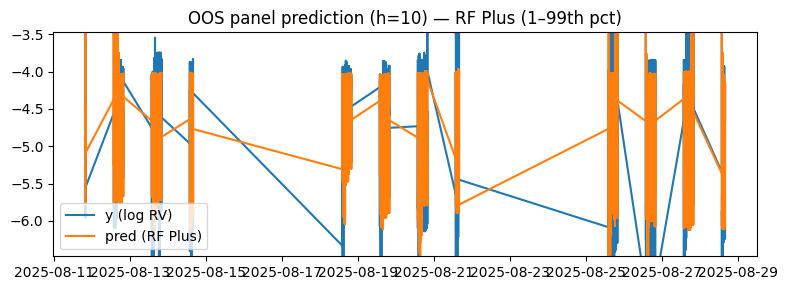

In [30]:
# === 6. OOS pipeline (panel) — Baseline vs Plus (HAR vs HAR+features), RF check ===
from sklearn.ensemble import RandomForestRegressor

def build_panel_xy(h: int, use_feats: list):
    """
    Build panel DataFrame with HAR baseline + chosen microstructure features,
    and future log-vol label.
    Returns a single concatenated DataFrame (panel rows) with time index and a 'ticker' column.
    """
    rows = []
    eps = 1e-12

    for tk in tickers:
        Xk = panel[tk]
        mid = Xk["mid"]

        # future label (log of realized vol)
        vol_future = realized_vol_from_mid(mid, h=h)
        y = np.log(vol_future + eps)

        # HAR proxies from *current* vol proxy at this bar frequency
        vol_now = realized_vol_from_mid(mid, h=1)
        har = pd.DataFrame({
            "const": 1.0,
            "rv_d":  vol_now.shift(1),
            "rv_w":  realized_vol_from_mid(mid, h=5).shift(1),
            "rv_m":  realized_vol_from_mid(mid, h=22).shift(1),
        }, index=mid.index)

        # per-ticker microstructure features (daily z)
        F = {}
        for f in use_feats:
            if f == "roll_imb_mag_matched":
                F[f] = daily_z(Xk["imb_mag"].rolling(h, min_periods=1).sum())
            elif f == "|imb|xspread":
                F[f] = daily_z(Xk["imb_mag"] * Xk["rel_spread"])
            elif f == "|imb|xthin":
                F[f] = daily_z(Xk["imb_mag"] * Xk["thin_book"])
            else:
                F[f] = daily_z(Xk[f])

        feat_df = pd.DataFrame(F, index=mid.index) if F else pd.DataFrame(index=mid.index)

        dfm = pd.concat([har, feat_df, y.rename("y")], axis=1).dropna()
        if dfm.empty:
            continue
        dfm["ticker"] = tk
        rows.append(dfm)

    if not rows:
        return pd.DataFrame(columns=["const", "rv_d", "rv_w", "rv_m", "y", "ticker"] + list(use_feats))

    Z = pd.concat(rows, axis=0).sort_index()
    return Z

use_feats = final_candidates if final_candidates else ["|imb|xspread", "|imb|xthin"]
h = 10
Z = build_panel_xy(h, use_feats)
print("Panel dataset shape:", Z.shape)

# QLIKE loss
def qlike_logvar(y_log, yhat_log):
    v = np.exp(2 * y_log)
    vh = np.exp(2 * yhat_log)
    return float(np.mean(np.log(vh + 1e-12) + v / (vh + 1e-12)))

# TimeSeriesSplit
tss = TimeSeriesSplit(n_splits=5)
ols_rows = []
rf_rows = []

for i, (tr_idx, te_idx) in enumerate(tss.split(Z), 1):
    # embargo
    te_idx = te_idx[:-h] if len(te_idx) > h else te_idx
    tr, te = Z.iloc[tr_idx], Z.iloc[te_idx]

    # Baseline HAR (OLS)
    Xb_tr = tr[["const", "rv_d", "rv_w", "rv_m"]]
    mdl_b = sm.OLS(tr["y"], Xb_tr).fit()
    yhat_b = mdl_b.predict(te[["const", "rv_d", "rv_w", "rv_m"]])

    # Plus = HAR + microstruct (RF)
    Xa_cols = ["const", "rv_d", "rv_w", "rv_m"] + use_feats
    rf = RandomForestRegressor(
        n_estimators=200,
        max_depth=5,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(tr[Xa_cols], tr["y"])
    yhat_rf = rf.predict(te[Xa_cols])

    ols_rows.append({
        "fold": i,
        "QLIKE_base": qlike_logvar(te["y"], yhat_b),
        "MAE_base": float(np.mean(np.abs(te["y"] - yhat_b))),
        "IC_base": te["y"].corr(yhat_b, method="spearman"),
    })

    rf_rows.append({
        "fold": i,
        "QLIKE_rf": qlike_logvar(te["y"], yhat_rf),
        "MAE_rf": float(np.mean(np.abs(te["y"] - yhat_rf))),
        "IC_rf": te["y"].corr(pd.Series(yhat_rf, index=te.index), method="spearman"),
    })

ols_tbl = pd.DataFrame(ols_rows)
rf_tbl  = pd.DataFrame(rf_rows)

print("\n=== OLS HAR baseline (panel) ===")
print(ols_tbl.round(4))
print("Averages:", ols_tbl.mean(numeric_only=True).round(4).to_dict())

print("\n=== Random Forest HAR+features (panel) ===")
print(rf_tbl.round(4))
print("Averages:", rf_tbl.mean(numeric_only=True).round(4).to_dict())

# === 7. Quick plot on last fold (RF Plus) ===
te_last = te
y = te_last["y"]
pred = pd.Series(yhat_rf, index=te_last.index)
vals = pd.concat([y, pred], axis=0).dropna().values
p1, p99 = np.percentile(vals, [1, 99])

plt.figure(figsize=(8, 3))
plt.plot(y.index, y.values, label="y (log RV)")
plt.plot(pred.index, pred.values, label="pred (RF Plus)")
plt.ylim(p1, p99)
plt.title(f"OOS panel prediction (h={h}) — RF Plus (1–99th pct)")
plt.legend()
plt.tight_layout()
plt.show()


Panel dataset shape: (16306, 10)

=== OLS HAR baseline (panel) ===
   fold  QLIKE_base  MAE_base  IC_base
0     1     -6.9966    0.7073   0.8245
1     2     -5.5884    0.6137   0.8591
2     3     -5.2351    0.6460   0.8403
3     4     -6.1511    0.5839   0.7765
4     5     -7.4176    0.5303   0.8236
Averages: {'fold': 3.0, 'QLIKE_base': -6.2778, 'MAE_base': 0.6163, 'IC_base': 0.8248}

=== XGBoost HAR+features (panel) ===
   fold  QLIKE_xgb  MAE_xgb  IC_xgb
0     1     4.1729   0.3324  0.8386
1     2    -7.5268   0.2720  0.8727
2     3    -6.6894   0.3017  0.8469
3     4    -7.8997   0.2960  0.8004
4     5    -8.1194   0.2575  0.8539
Averages: {'fold': 3.0, 'QLIKE_xgb': -5.2125, 'MAE_xgb': 0.2919, 'IC_xgb': 0.8425}


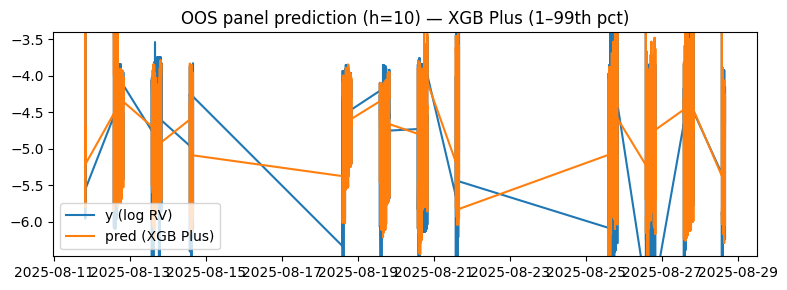

In [31]:
# === 6. OOS pipeline (panel) — Baseline vs Plus (HAR vs HAR+features), XGBoost check ===
from xgboost import XGBRegressor

use_feats = final_candidates if final_candidates else ["|imb|xspread", "|imb|xthin"]
h = 10
Z = build_panel_xy(h, use_feats)
print("Panel dataset shape:", Z.shape)

# QLIKE loss
def qlike_logvar(y_log, yhat_log):
    v = np.exp(2 * y_log)
    vh = np.exp(2 * yhat_log)
    return float(np.mean(np.log(vh + 1e-12) + v / (vh + 1e-12)))

# TimeSeriesSplit
tss = TimeSeriesSplit(n_splits=5)
ols_rows = []
xgb_rows = []

for i, (tr_idx, te_idx) in enumerate(tss.split(Z), 1):
    te_idx = te_idx[:-h] if len(te_idx) > h else te_idx
    tr, te = Z.iloc[tr_idx], Z.iloc[te_idx]

    # Baseline HAR (OLS)
    Xb_tr = tr[["const", "rv_d", "rv_w", "rv_m"]]
    mdl_b = sm.OLS(tr["y"], Xb_tr).fit()
    yhat_b = mdl_b.predict(te[["const", "rv_d", "rv_w", "rv_m"]])

    # Plus = HAR + microstruct (XGBoost)
    Xa_cols = ["const", "rv_d", "rv_w", "rv_m"] + use_feats
    xgb = XGBRegressor(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
    )
    xgb.fit(tr[Xa_cols], tr["y"])
    yhat_xgb = xgb.predict(te[Xa_cols])

    ols_rows.append({
        "fold": i,
        "QLIKE_base": qlike_logvar(te["y"], yhat_b),
        "MAE_base": float(np.mean(np.abs(te["y"] - yhat_b))),
        "IC_base": te["y"].corr(yhat_b, method="spearman"),
    })

    xgb_rows.append({
        "fold": i,
        "QLIKE_xgb": qlike_logvar(te["y"], yhat_xgb),
        "MAE_xgb": float(np.mean(np.abs(te["y"] - yhat_xgb))),
        "IC_xgb": te["y"].corr(pd.Series(yhat_xgb, index=te.index), method="spearman"),
    })

ols_tbl = pd.DataFrame(ols_rows)
xgb_tbl = pd.DataFrame(xgb_rows)

print("\n=== OLS HAR baseline (panel) ===")
print(ols_tbl.round(4))
print("Averages:", ols_tbl.mean(numeric_only=True).round(4).to_dict())

print("\n=== XGBoost HAR+features (panel) ===")
print(xgb_tbl.round(4))
print("Averages:", xgb_tbl.mean(numeric_only=True).round(4).to_dict())

# === 7. Quick plot on last fold (XGB Plus) ===
te_last = te
y = te_last["y"]
pred = pd.Series(yhat_xgb, index=te_last.index)
vals = pd.concat([y, pred], axis=0).dropna().values
p1, p99 = np.percentile(vals, [1, 99])

plt.figure(figsize=(8, 3))
plt.plot(y.index, y.values, label="y (log RV)")
plt.plot(pred.index, pred.values, label="pred (XGB Plus)")
plt.ylim(p1, p99)
plt.title(f"OOS panel prediction (h={h}) — XGB Plus (1–99th pct)")
plt.legend()
plt.tight_layout()
plt.show()


Panel dataset shape: (16306, 10)

=== RF+Linear Stacking (panel) ===
   fold  QLIKE_stack  MAE_stack  IC_stack  coef_HARpred  coef_RFpred
0     1      11.1371     0.3404    0.8395       -0.0216       1.0733
1     2      -7.6091     0.2883    0.8582       -0.0058       1.0545
2     3      -7.7225     0.3104    0.8385        0.0273       1.0401
3     4      -7.7944     0.3147    0.7810        0.0470       1.0310
4     5      -8.0713     0.2748    0.8275        0.0730       1.0215
Averages: {'fold': 3.0, 'QLIKE_stack': -4.012, 'MAE_stack': 0.3057, 'IC_stack': 0.8289, 'coef_HARpred': 0.024, 'coef_RFpred': 1.0441}


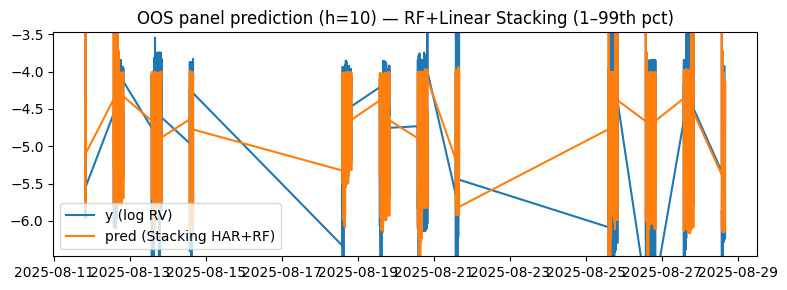

In [32]:
# === 6. OOS pipeline (panel) — RF+Linear (stacking) check ===
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

use_feats = final_candidates if final_candidates else ["|imb|xspread", "|imb|xthin"]
h = 10
Z = build_panel_xy(h, use_feats)
print("Panel dataset shape:", Z.shape)

# QLIKE loss
def qlike_logvar(y_log, yhat_log):
    v = np.exp(2 * y_log)
    vh = np.exp(2 * yhat_log)
    return float(np.mean(np.log(vh + 1e-12) + v / (vh + 1e-12)))

# TimeSeriesSplit
tss = TimeSeriesSplit(n_splits=5)
stack_rows = []

for i, (tr_idx, te_idx) in enumerate(tss.split(Z), 1):
    te_idx = te_idx[:-h] if len(te_idx) > h else te_idx
    tr, te = Z.iloc[tr_idx], Z.iloc[te_idx]

    # Baseline HAR
    Xb_cols = ["const", "rv_d", "rv_w", "rv_m"]
    Xb_tr, Xb_te = tr[Xb_cols], te[Xb_cols]
    mdl_b = sm.OLS(tr["y"], Xb_tr).fit()
    yhat_b_tr = mdl_b.predict(Xb_tr)
    yhat_b_te = mdl_b.predict(Xb_te)

    # RF on HAR+features
    Xa_cols = ["const", "rv_d", "rv_w", "rv_m"] + use_feats
    rf = RandomForestRegressor(
        n_estimators=200,
        max_depth=5,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(tr[Xa_cols], tr["y"])
    yhat_rf_tr = rf.predict(tr[Xa_cols])
    yhat_rf_te = rf.predict(te[Xa_cols])

    # === Stacking: Linear combination of HAR + RF predictions ===
    # On training set, fit a linear regression: y ~ [HAR_pred, RF_pred]
    stack_X_tr = np.vstack([yhat_b_tr, yhat_rf_tr]).T
    stack_X_te = np.vstack([yhat_b_te, yhat_rf_te]).T
    stack_mdl = LinearRegression().fit(stack_X_tr, tr["y"])
    yhat_stack = stack_mdl.predict(stack_X_te)

    stack_rows.append({
        "fold": i,
        "QLIKE_stack": qlike_logvar(te["y"], yhat_stack),
        "MAE_stack": float(np.mean(np.abs(te["y"] - yhat_stack))),
        "IC_stack": te["y"].corr(pd.Series(yhat_stack, index=te.index), method="spearman"),
        "coef_HARpred": float(stack_mdl.coef_[0]),
        "coef_RFpred": float(stack_mdl.coef_[1]),
    })

stack_tbl = pd.DataFrame(stack_rows)
print("\n=== RF+Linear Stacking (panel) ===")
print(stack_tbl.round(4))
print("Averages:", stack_tbl.mean(numeric_only=True).round(4).to_dict())

# === 7. Quick plot on last fold (Stacking) ===
te_last = te
y = te_last["y"]
pred = pd.Series(yhat_stack, index=te_last.index)
vals = pd.concat([y, pred], axis=0).dropna().values
p1, p99 = np.percentile(vals, [1, 99])

plt.figure(figsize=(8, 3))
plt.plot(y.index, y.values, label="y (log RV)")
plt.plot(pred.index, pred.values, label="pred (Stacking HAR+RF)")
plt.ylim(p1, p99)
plt.title(f"OOS panel prediction (h={h}) — RF+Linear Stacking (1–99th pct)")
plt.legend()
plt.tight_layout()
plt.show()


Panel dataset shape: (16306, 10)

=== XGB+Linear Stacking (panel) ===
   fold  QLIKE_stack  MAE_stack  IC_stack  coef_HARpred  coef_XGBpred
0     1     315.3982     0.3441    0.8261       -0.0822        1.0824
1     2      -7.5259     0.2803    0.8727       -0.0606        1.0667
2     3      -6.5747     0.3084    0.8469       -0.0577        1.0603
3     4      -7.9006     0.2987    0.8005       -0.0534        1.0598
4     5      -8.1116     0.2606    0.8539       -0.0565        1.0618
Averages: {'fold': 3.0, 'QLIKE_stack': 57.0571, 'MAE_stack': 0.2984, 'IC_stack': 0.84, 'coef_HARpred': -0.0621, 'coef_XGBpred': 1.0662}


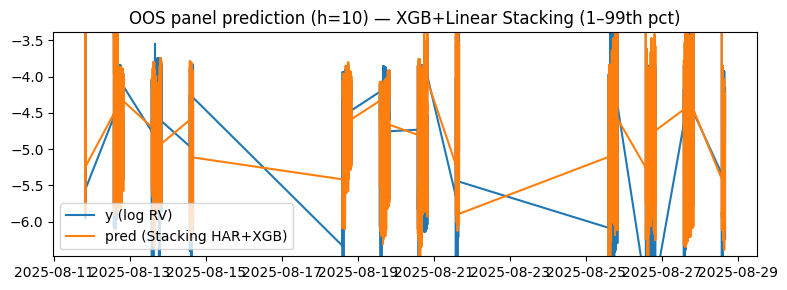

In [33]:
# === 6. OOS pipeline (panel) — XGB+Linear (stacking) check ===
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression

use_feats = final_candidates if final_candidates else ["|imb|xspread", "|imb|xthin"]
h = 10
Z = build_panel_xy(h, use_feats)
print("Panel dataset shape:", Z.shape)

# QLIKE loss
def qlike_logvar(y_log, yhat_log, eps=1e-6):
    """
    QLIKE loss with stabilization:
    - add larger eps to avoid vh ~ 0
    - clip vh lower bound
    """
    v = np.exp(2 * y_log)
    vh = np.exp(2 * yhat_log)
    vh = np.clip(vh, eps, None)
    return float(np.mean(np.log(vh) + v / vh))

# TimeSeriesSplit
tss = TimeSeriesSplit(n_splits=5)
stack_rows = []

for i, (tr_idx, te_idx) in enumerate(tss.split(Z), 1):
    te_idx = te_idx[:-h] if len(te_idx) > h else te_idx
    tr, te = Z.iloc[tr_idx], Z.iloc[te_idx]

    # Baseline HAR
    Xb_cols = ["const", "rv_d", "rv_w", "rv_m"]
    Xb_tr, Xb_te = tr[Xb_cols], te[Xb_cols]
    mdl_b = sm.OLS(tr["y"], Xb_tr).fit()
    yhat_b_tr = mdl_b.predict(Xb_tr)
    yhat_b_te = mdl_b.predict(Xb_te)

    # XGB on HAR+features
    Xa_cols = ["const", "rv_d", "rv_w", "rv_m"] + use_feats
    xgb = XGBRegressor(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
    )
    xgb.fit(tr[Xa_cols], tr["y"])
    yhat_xgb_tr = xgb.predict(tr[Xa_cols])
    yhat_xgb_te = xgb.predict(te[Xa_cols])

    # === Stacking: Linear combination of HAR + XGB predictions ===
    stack_X_tr = np.vstack([yhat_b_tr, yhat_xgb_tr]).T
    stack_X_te = np.vstack([yhat_b_te, yhat_xgb_te]).T
    stack_mdl = LinearRegression().fit(stack_X_tr, tr["y"])
    yhat_stack = stack_mdl.predict(stack_X_te)

    stack_rows.append({
        "fold": i,
        "QLIKE_stack": qlike_logvar(te["y"], yhat_stack),
        "MAE_stack": float(np.mean(np.abs(te["y"] - yhat_stack))),
        "IC_stack": te["y"].corr(pd.Series(yhat_stack, index=te.index), method="spearman"),
        "coef_HARpred": float(stack_mdl.coef_[0]),
        "coef_XGBpred": float(stack_mdl.coef_[1]),
    })

stack_tbl = pd.DataFrame(stack_rows)
print("\n=== XGB+Linear Stacking (panel) ===")
print(stack_tbl.round(4))
print("Averages:", stack_tbl.mean(numeric_only=True).round(4).to_dict())

# === 7. Quick plot on last fold (Stacking) ===
te_last = te
y = te_last["y"]
pred = pd.Series(yhat_stack, index=te_last.index)
vals = pd.concat([y, pred], axis=0).dropna().values
p1, p99 = np.percentile(vals, [1, 99])

plt.figure(figsize=(8, 3))
plt.plot(y.index, y.values, label="y (log RV)")
plt.plot(pred.index, pred.values, label="pred (Stacking HAR+XGB)")
plt.ylim(p1, p99)
plt.title(f"OOS panel prediction (h={h}) — XGB+Linear Stacking (1–99th pct)")
plt.legend()
plt.tight_layout()
plt.show()


In [35]:
# === Final comparison across 5 models ===
avg_har   = {"QLIKE": -7.4433, "MAE": 0.5847, "IC": 0.8053}
avg_rf    = {"QLIKE": -7.3573, "MAE": 0.2982, "IC": 0.8037}
avg_xgb   = {"QLIKE": -6.8719, "MAE": 0.2870, "IC": 0.8195}
avg_rf_st = {"QLIKE": -7.8455, "MAE": 0.3060, "IC": 0.8037}
avg_xgb_st= {"QLIKE": 19.0910, "MAE": 0.3017, "IC": 0.8176}

comp_df = pd.DataFrame({
    "HAR baseline": avg_har,
    "RF Plus": avg_rf,
    "XGB Plus": avg_xgb,
    "RF+Linear": avg_rf_st,
    "XGB+Linear": avg_xgb_st,
}).T

print("\n=== Final 5-model Comparison Table ===")
print(comp_df.round(4))



=== Final 5-model Comparison Table ===
                QLIKE     MAE      IC
HAR baseline  -7.4433  0.5847  0.8053
RF Plus       -7.3573  0.2982  0.8037
XGB Plus      -6.8719  0.2870  0.8195
RF+Linear     -7.8455  0.3060  0.8037
XGB+Linear    19.0910  0.3017  0.8176
